# Overlapping score distributions (two datasets)

Compare signed classifier scores from **two** `compare_model_predictions.py` CSVs, one panel per model:

- **SVM:** `SVM_hyperplane_distance` (or `SVM_distance`)
- **GNN:** `{model}_logit_margin` (logit_AMP − logit_nonAMP)

Histograms are normalized (density) and overlaid per dataset. GNN panels share a common x-axis; SVM uses its own scale.

Notebook version of `scripts/data_evaluation/plot_comparison_overlapping_logit_distributions.py`. Edit paths in the first code cell, then run all cells.

In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("../sequence_to_svm_minimal").expanduser().resolve()

# --- edit these paths ---
# Paths are relative to PROJECT_ROOT unless absolute.
# Example that produced overlapping_score_distributions_CPPs_vs_Figshare_Dataset_20260420_142956.png:
CSV1 = "data/test/CPPs/generated/model_comparison_latest.csv"
CSV2 = "data/test/Figshare/generated/model_comparison_latest.csv"

DATASET_NAME1: str | None = "CPPs"          # None → infer from CSV path
DATASET_NAME2: str | None = "Figshare Dataset"

BINS = 50
LAYOUT = "rows"  # "rows" (stacked) or "cols" (side by side)
DROP_NEGATIVE = False  # if True, drop scores < 0 before plotting

DISPLAY_ORDER = ["SVM", "ESM-only", "ESM+Geo20", "ESM+QSAR12", "ESM+Combined32"]

# Plot titles only — CSV columns still use keys from compare_model_predictions.py (e.g. ESM-only_pred).
MODEL_DISPLAY_NAMES = {
    "ESM-only": "GNN",
}

plt.style.use("seaborn-v0_8-whitegrid")


def _model_display_name(model: str) -> str:
    return MODEL_DISPLAY_NAMES.get(model, model)


def _resolve(path_str: str) -> Path:
    p = Path(path_str).expanduser()
    if not p.is_absolute():
        p = PROJECT_ROOT / p
    return p.resolve()


def _models_from_dfs(df1: pd.DataFrame, df2: pd.DataFrame) -> list[str]:
    models1 = {c[:-5] for c in df1.columns if c.endswith("_pred")}
    models2 = {c[:-5] for c in df2.columns if c.endswith("_pred")}
    models = models1.intersection(models2)
    ordered = [m for m in DISPLAY_ORDER if m in models]
    for m in models:
        if m not in ordered:
            ordered.append(m)
    return ordered


def _signed_score_column(df: pd.DataFrame, model: str) -> str | None:
    if model == "SVM":
        for col in ("SVM_hyperplane_distance", "SVM_distance"):
            if col in df.columns:
                return col
        return None
    col = f"{model}_logit_margin"
    return col if col in df.columns else None


def _gnn_shared_x_range(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    models: list[str],
    *,
    drop_negative: bool = False,
    pad_frac: float = 0.05,
) -> tuple[float, float] | None:
    chunks: list[np.ndarray] = []
    for df in (df1, df2):
        for m in models:
            if m == "SVM":
                continue
            col = _signed_score_column(df, m)
            if col is None:
                continue
            x = pd.to_numeric(df[col], errors="coerce").dropna().to_numpy()
            if drop_negative:
                x = x[x >= 0]
            if x.size:
                chunks.append(x)
    if not chunks:
        return None
    all_x = np.concatenate(chunks)
    lo = float(np.nanmin(all_x))
    hi = float(np.nanmax(all_x))
    span = hi - lo
    pad = pad_frac * span if span > 0 else 1.0
    return (lo - pad, hi + pad)


def _dataset_name_from_csv_path(csv_path: Path) -> str:
    parts_l = [p.lower() for p in csv_path.parts]
    if "generated" in parts_l:
        i = parts_l.index("generated")
        if i - 1 >= 0:
            return csv_path.parts[i - 1]
    return csv_path.stem


def _stat_text(x: np.ndarray, name: str, *, drop_negative: bool) -> str:
    pos_x = x if drop_negative else x[x > 0]
    suffix = "" if drop_negative else " (val > 0)"
    if pos_x.size:
        mu = float(np.mean(pos_x))
        var = float(np.var(pos_x))
        return f"{name}{suffix}: μ={mu:.2f} var={var:.2f} (n={pos_x.size})"
    return f"{name}: No positive scores"


def plot_overlapping_distributions(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    models: list[str],
    *,
    bins: int,
    layout: str,
    dataset_name1: str,
    dataset_name2: str,
    drop_negative: bool = False,
):
    n = len(models)
    if n == 0:
        raise ValueError("No models to plot.")

    gnn_xlim = _gnn_shared_x_range(df1, df2, models, drop_negative=drop_negative)
    gnn_bin_edges = np.linspace(gnn_xlim[0], gnn_xlim[1], bins + 1) if gnn_xlim is not None else None

    if layout == "cols":
        nrows, ncols = 1, n
        figsize = (3.6 * n, 3.6)
    else:
        nrows, ncols = n, 1
        figsize = (8.5, 3.6 * n)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    ax_flat = axes.ravel()
    color1, color2 = "tab:blue", "tab:orange"

    for i, model in enumerate(models):
        ax = ax_flat[i]
        col1 = _signed_score_column(df1, model)
        col2 = _signed_score_column(df2, model)
        if col1 is None or col2 is None:
            ax.set_visible(False)
            continue

        score1 = pd.to_numeric(df1[col1], errors="coerce").to_numpy()
        score2 = pd.to_numeric(df2[col2], errors="coerce").to_numpy()
        score1 = score1[np.isfinite(score1)]
        score2 = score2[np.isfinite(score2)]
        if drop_negative:
            score1 = score1[score1 >= 0]
            score2 = score2[score2 >= 0]

        stat1 = _stat_text(score1, dataset_name1, drop_negative=drop_negative)
        stat2 = _stat_text(score2, dataset_name2, drop_negative=drop_negative)
        hbins = gnn_bin_edges if (model != "SVM" and gnn_bin_edges is not None) else bins

        if score1.size > 0:
            ax.hist(
                score1,
                bins=hbins,
                density=True,
                color=color1,
                edgecolor="black",
                linewidth=0.6,
                alpha=0.6,
                label=stat1,
            )
        if score2.size > 0:
            ax.hist(
                score2,
                bins=hbins,
                density=True,
                color=color2,
                edgecolor="black",
                linewidth=0.6,
                alpha=0.6,
                label=stat2,
            )

        if model != "SVM" and gnn_xlim is not None:
            ax.set_xlim(gnn_xlim)

        subtitle = "SVM decision function" if model == "SVM" else "Raw logit outputs"
        xlabel = "Hyperplane distance" if model == "SVM" else "Logit margin"
        ax.axvline(0.0, color="black", linestyle="--", linewidth=1, alpha=0.75)
        ax.set_ylabel("Density")
        ax.set_xlabel(xlabel, labelpad=8)
        ax.set_title(f"{_model_display_name(model)}\n({subtitle})", pad=10)
        ax.legend(loc="upper right", fontsize=8, framealpha=0.92, borderpad=0.6)

        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.45)

    fig.tight_layout(rect=[0, 0, 1, 0.93], h_pad=3.2, pad=1.6)
    fig.suptitle(
        f"Overlapping score distribution — {dataset_name1} vs {dataset_name2}",
        fontsize=13,
        fontweight="bold",
        y=0.98,
    )
    return fig


def _prob_amp_column(df: pd.DataFrame, model: str) -> str | None:
    col = f"{model}_prob_AMP"
    return col if col in df.columns else None


def _stat_text_prob(x: np.ndarray, name: str) -> str:
    if x.size:
        mu = float(np.mean(x))
        var = float(np.var(x))
        return f"{name}: μ={mu:.2f} var={var:.2f} (n={x.size})"
    return f"{name}: no data"


def plot_overlapping_prob_distributions(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    models: list[str],
    *,
    bins: int,
    layout: str,
    dataset_name1: str,
    dataset_name2: str,
):
    n = len(models)
    if n == 0:
        raise ValueError("No models to plot.")

    prob_xlim = (-0.02, 1.02)
    prob_bin_edges = np.linspace(prob_xlim[0], prob_xlim[1], bins + 1)

    if layout == "cols":
        nrows, ncols = 1, n
        figsize = (3.6 * n, 3.6)
    else:
        nrows, ncols = n, 1
        figsize = (8.5, 3.6 * n)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    ax_flat = axes.ravel()
    color1, color2 = "tab:blue", "tab:orange"

    for i, model in enumerate(models):
        ax = ax_flat[i]
        col1 = _prob_amp_column(df1, model)
        col2 = _prob_amp_column(df2, model)
        if col1 is None or col2 is None:
            ax.set_visible(False)
            continue

        score1 = pd.to_numeric(df1[col1], errors="coerce").to_numpy()
        score2 = pd.to_numeric(df2[col2], errors="coerce").to_numpy()
        score1 = score1[np.isfinite(score1)]
        score2 = score2[np.isfinite(score2)]

        stat1 = _stat_text_prob(score1, dataset_name1)
        stat2 = _stat_text_prob(score2, dataset_name2)

        if score1.size > 0:
            ax.hist(
                score1,
                bins=prob_bin_edges,
                density=True,
                color=color1,
                edgecolor="black",
                linewidth=0.6,
                alpha=0.6,
                label=stat1,
            )
        if score2.size > 0:
            ax.hist(
                score2,
                bins=prob_bin_edges,
                density=True,
                color=color2,
                edgecolor="black",
                linewidth=0.6,
                alpha=0.6,
                label=stat2,
            )

        ax.set_xlim(prob_xlim)
        ax.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.75)
        ax.set_ylabel("Density")
        ax.set_xlabel("P(AMP)", labelpad=8)
        ax.set_title(f"{_model_display_name(model)}\n(Calibrated probability)", pad=10)
        ax.legend(loc="upper right", fontsize=8, framealpha=0.92, borderpad=0.6)

        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.45)

    fig.tight_layout(rect=[0, 0, 1, 0.93], h_pad=3.2, pad=1.6)
    fig.suptitle(
        f"Overlapping P(AMP) distribution — {dataset_name1} vs {dataset_name2}",
        fontsize=13,
        fontweight="bold",
        y=0.98,
    )
    return fig


csv1_path = _resolve(CSV1)
csv2_path = _resolve(CSV2)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("CSV1:", csv1_path)
print("CSV2:", csv2_path)

PROJECT_ROOT: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal
CSV1: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\test\CPPs\generated\model_comparison_latest.csv
CSV2: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\test\Figshare\generated\model_comparison_latest.csv


In [3]:
if not csv1_path.is_file():
    raise FileNotFoundError(f"CSV1 not found: {csv1_path}")
if not csv2_path.is_file():
    raise FileNotFoundError(f"CSV2 not found: {csv2_path}")

df1 = pd.read_csv(csv1_path)
df2 = pd.read_csv(csv2_path)
if df1.empty or df2.empty:
    raise ValueError("One or both CSVs are empty.")

models = _models_from_dfs(df1, df2)
if not models:
    raise ValueError("No matching *_pred columns found in both CSVs.")

dataset_name1 = DATASET_NAME1 or _dataset_name_from_csv_path(csv1_path)
dataset_name2 = DATASET_NAME2 or _dataset_name_from_csv_path(csv2_path)

print(f"Dataset 1 ({dataset_name1}): {len(df1):,} rows")
print(f"Dataset 2 ({dataset_name2}): {len(df2):,} rows")
print(f"Models: {models}")

Dataset 1 (CPPs): 708 rows
Dataset 2 (Figshare Dataset): 4,887 rows
Models: ['SVM', 'ESM-only']


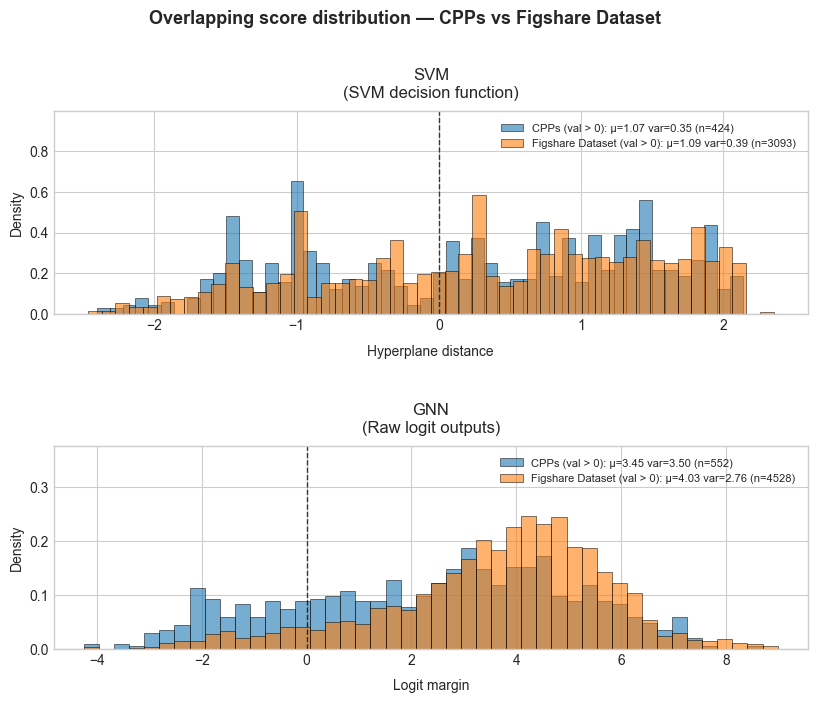

In [4]:
plot_overlapping_distributions(
    df1,
    df2,
    models,
    bins=BINS,
    layout=LAYOUT,
    dataset_name1=dataset_name1,
    dataset_name2=dataset_name2,
    drop_negative=DROP_NEGATIVE,
)
plt.show()

## P(AMP) distributions

Same layout as above, using `{model}_prob_AMP` (calibrated probability of AMP) instead of raw logits or hyperplane distance.

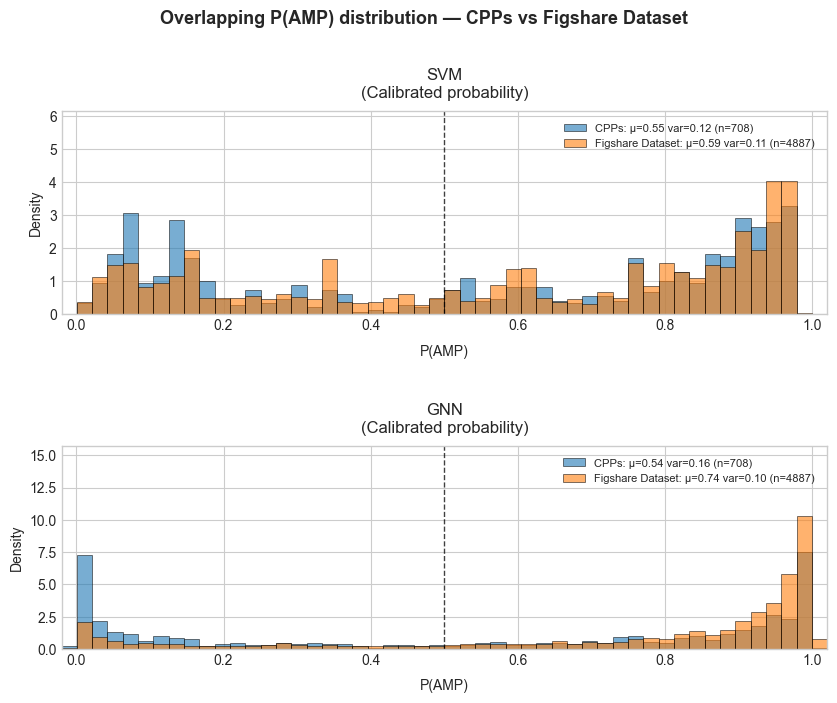

In [5]:
plot_overlapping_prob_distributions(
    df1,
    df2,
    models,
    bins=BINS,
    layout=LAYOUT,
    dataset_name1=dataset_name1,
    dataset_name2=dataset_name2,
)
plt.show()